# 1D Advection diffusion equation: $$ u_x - v*u_{xx} = f(x) $$


Case1: $$f(x) = 2 $$


Testing with v = 0.1
Training ... 
Number of collocation points: 1000
Trial 1: Error=4.1411e-03, BC_Error=2.3782e-05, Cond=3.42e+19
Trial 2: Error=1.7868e-03, BC_Error=1.0305e-05, Cond=2.41e+19
Trial 3: Error=2.9585e-03, BC_Error=1.6978e-05, Cond=8.21e+19
Trial 4: Error=6.3780e-04, BC_Error=3.6467e-06, Cond=5.55e+19
Trial 5: Error=8.1476e-04, BC_Error=4.6532e-06, Cond=1.14e+19
Trial 6: Error=4.5013e-04, BC_Error=2.5850e-06, Cond=9.63e+19
Trial 7: Error=1.7008e-04, BC_Error=9.6613e-07, Cond=1.84e+19
Trial 8: Error=6.9872e-04, BC_Error=4.0106e-06, Cond=4.77e+18
Trial 9: Error=3.9280e-04, BC_Error=2.2244e-06, Cond=4.00e+19
Trial 10: Error=2.0434e-03, BC_Error=1.1652e-05, Cond=7.53e+18

Best solution selected with error: 1.7974e-04
Final condition number: 1.84e+19


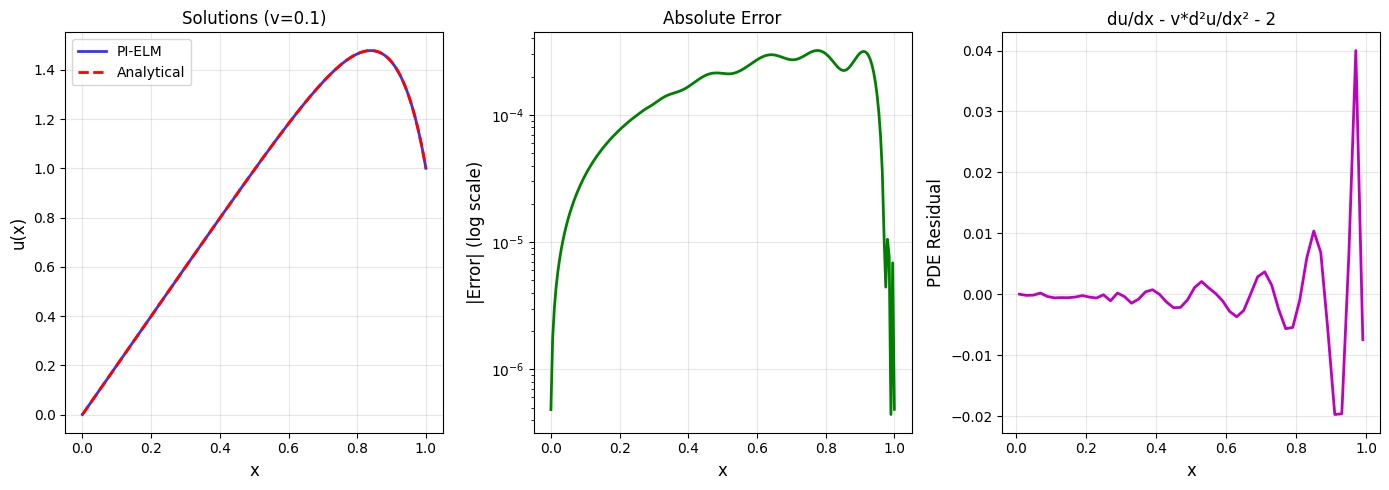


Mean Absolute Error: 1.725648e-04
Max Absolute Error: 3.209081e-04

Boundary Check:
u(0) - Predicted: -0.000000, Expected: 0.0, Error: 4.818260e-07
u(1) - Predicted: 1.000000, Expected: 1.0, Error: 4.843052e-07

Testing with v = 0.5
Training ... 
Number of collocation points: 1000
Trial 1: Error=8.8987e-07, BC_Error=1.7808e-08, Cond=4.83e+19
Trial 2: Error=5.3880e-07, BC_Error=7.5835e-09, Cond=5.43e+19
Trial 3: Error=9.2638e-07, BC_Error=1.8962e-08, Cond=3.30e+19
Trial 4: Error=1.0541e-06, BC_Error=6.4494e-09, Cond=1.51e+19
Trial 5: Error=4.6444e-07, BC_Error=7.5296e-09, Cond=1.14e+20
Trial 6: Error=2.2032e-07, BC_Error=2.2545e-09, Cond=2.14e+20
Trial 7: Error=1.9140e-07, BC_Error=4.7117e-10, Cond=7.93e+19
Trial 8: Error=8.8588e-07, BC_Error=6.3967e-09, Cond=1.73e+19
Trial 9: Error=4.6934e-07, BC_Error=2.7824e-09, Cond=7.51e+19
Trial 10: Error=2.1213e-06, BC_Error=2.8344e-08, Cond=1.04e+19

Best solution selected with error: 1.9611e-07
Final condition number: 7.93e+19


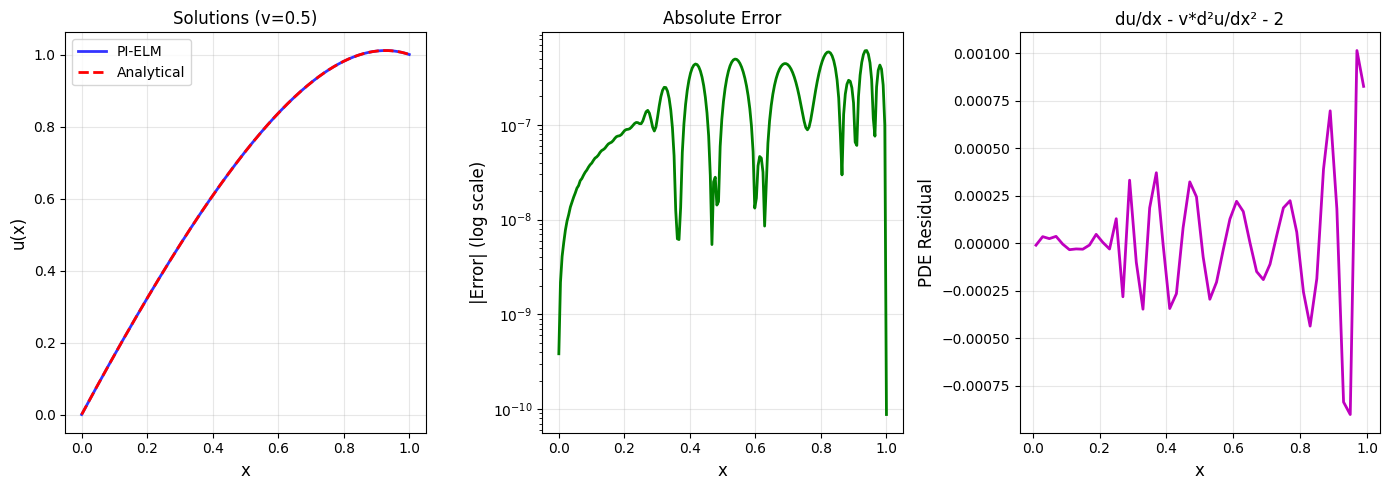


Mean Absolute Error: 1.942034e-07
Max Absolute Error: 6.106239e-07

Boundary Check:
u(0) - Predicted: -0.000000, Expected: 0.0, Error: 3.835890e-10
u(1) - Predicted: 1.000000, Expected: 1.0, Error: 8.758105e-11

Testing with v = 1.0
Training ... 
Number of collocation points: 1000
Trial 1: Error=8.5966e-08, BC_Error=9.5911e-09, Cond=1.95e+20
Trial 2: Error=5.7703e-08, BC_Error=3.2598e-09, Cond=8.93e+19
Trial 3: Error=3.7771e-08, BC_Error=4.3326e-09, Cond=8.92e+19
Trial 4: Error=1.6597e-07, BC_Error=7.1168e-09, Cond=1.04e+20
Trial 5: Error=4.8316e-08, BC_Error=3.2575e-09, Cond=1.57e+20
Trial 6: Error=4.6818e-08, BC_Error=4.6163e-09, Cond=1.20e+20
Trial 7: Error=4.1383e-08, BC_Error=3.2502e-09, Cond=2.30e+21
Trial 8: Error=1.4178e-07, BC_Error=7.7569e-09, Cond=5.70e+19
Trial 9: Error=4.0362e-08, BC_Error=4.4453e-09, Cond=4.04e+20
Trial 10: Error=7.7126e-07, BC_Error=1.3245e-08, Cond=3.76e+19

Best solution selected with error: 7.3885e-08
Final condition number: 2.30e+21


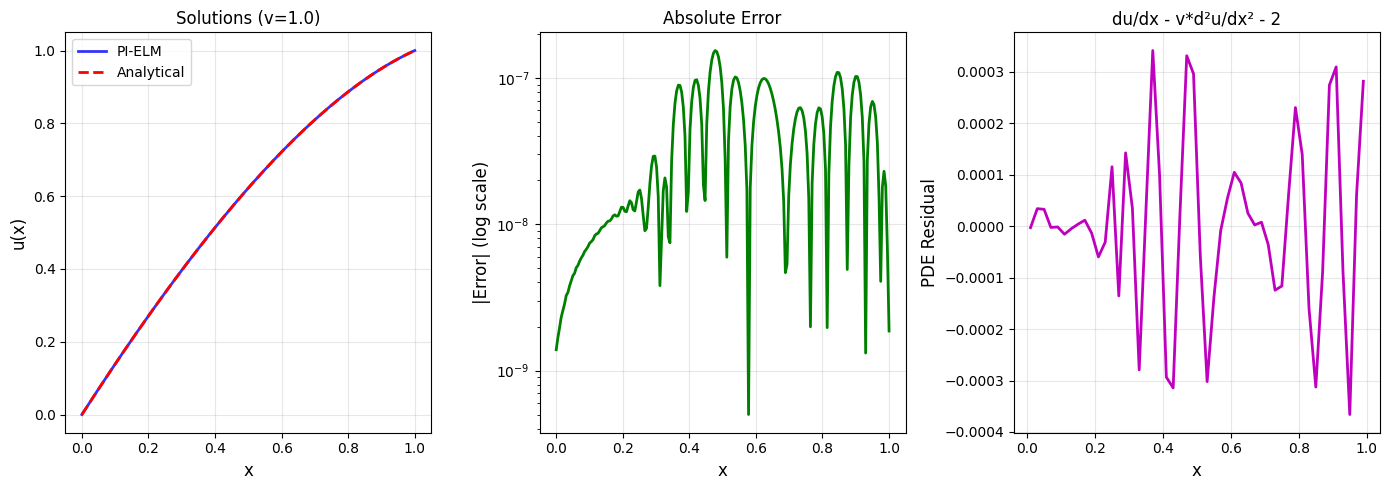


Mean Absolute Error: 4.200515e-08
Max Absolute Error: 1.540461e-07

Boundary Check:
u(0) - Predicted: 0.000000, Expected: 0.0, Error: 1.387696e-09
u(1) - Predicted: 1.000000, Expected: 1.0, Error: 1.862502e-09


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class PIELM():
    def __init__(self, n_hidden=100, v=0.1):
        self.v = v
        self.n_hidden = n_hidden
        self.W = None
        self.b = None
        self.C = None

    def _phi(self, Z):
        """Activation function"""
        return np.tanh(Z)

    def _phi_p(self, Z):
        """First derivative"""
        return 1 - np.tanh(Z)**2

    def _phi_pp(self, Z):
        """Second derivative"""
        return -2 * np.tanh(Z) * (1 - np.tanh(Z)**2)

    def _compute_Z(self, x):
        """Compute Z = W*x + b"""
        return self.W * x.reshape(1, -1) + self.b

    def _generate_collocation_points(self, Nc, x_min=0., x_max=1.):
        # Chebyshev-like clustering
        # x_uniform = np.linspace(x_min, x_max, Nc // 2)
        # theta = np.linspace(0, np.pi, Nc // 2 + 1)[:-1]
        # x_clustered = 0.75 + 0.25 * np.cos(theta)  # Cluster in [0.5, 1]

        # x_coll = np.unique(np.concatenate([x_uniform, x_clustered]))
        # x_coll = x_coll[(x_coll > x_min) & (x_coll < x_max)]
        x_coll = np.linspace(x_min, x_max, Nc)
        return x_coll

    def train(self, Nc=100, x_min=0., x_max=1., ul=0., ur=1., bc_weight=100.0, n_trials=5):
        print("Training ... ")

        # Generate collocation points
        x_coll = self._generate_collocation_points(Nc, x_min, x_max)
        print(f"Number of collocation points: {len(x_coll)}")

        # Boundary points
        x_bc = np.array([x_min, x_max])
        u_bc = np.array([[ul], [ur]])

        best_error = np.inf
        best_C = None
        best_W = None
        best_b = None

        for trial in range(n_trials):
            # Initialize random weights
            # For boundary layer problems, use wider range of frequencies
            np.random.seed(42 + trial)

            W_low = np.random.randn(self.n_hidden // 2, 1) * 5.0
            W_high = np.random.randn(self.n_hidden // 2, 1) * 50.0
            self.W = np.vstack([W_low, W_high])
            self.b = np.random.randn(self.n_hidden, 1) * 5.0

            # Collocation points
            Z_coll = self._compute_Z(x_coll)
            phi_p_coll = self._phi_p(Z_coll)
            phi_pp_coll = self._phi_pp(Z_coll)

            H_op = (phi_p_coll * self.W).T - self.v * (phi_pp_coll * self.W**2).T

            Z_bc = self._compute_Z(x_bc)
            H_bc = self._phi(Z_bc).T

            H_bc_weighted = bc_weight * H_bc

            f_coll = 2 * np.ones((len(x_coll), 1))
            u_bc_weighted = bc_weight * u_bc
            H_total = np.vstack([H_op, H_bc_weighted])
            b_total = np.vstack([f_coll, u_bc_weighted])

            HTH = H_total.T @ H_total
            HTb = H_total.T @ b_total

            # Adaptive regularization
            cond = np.linalg.cond(HTH)
            if cond > 1e12:
                lambda_reg = 1e-1
            elif cond > 1e8:
                lambda_reg = 1e-2
            else:
                lambda_reg = 1e-3

            C_trial = np.linalg.solve(HTH + lambda_reg * np.eye(self.n_hidden), HTb)

            # Evaluate on training points
            self.C = C_trial
            x_eval = np.linspace(x_min, x_max, 50)
            y_pred = self.predict(x_eval)
            y_exact = self.analytical_solution(x_eval)
            error = np.mean(np.abs(y_pred.flatten() - y_exact))

            # Check boundary conditions
            u0_pred = self.predict(np.array([x_min]))[0, 0]
            u1_pred = self.predict(np.array([x_max]))[0, 0]
            bc_error = abs(u0_pred - ul) + abs(u1_pred - ur)

            total_error = error + 10.0 * bc_error  # Heavily penalize BC violations

            if total_error < best_error:
                best_error = total_error
                best_C = C_trial
                best_W = self.W.copy()
                best_b = self.b.copy()
                best_cond = cond

            print(f"Trial {trial+1}: Error={error:.4e}, BC_Error={bc_error:.4e}, Cond={cond:.2e}")

        # Use best solution
        self.W = best_W
        self.b = best_b
        self.C = best_C

        print(f"\nBest solution selected with error: {best_error:.4e}")
        print(f"Final condition number: {best_cond:.2e}")

    def predict(self, x_test):
        """Predict u at test points"""
        Z_test = self._compute_Z(x_test)
        phi_test = self._phi(Z_test).T
        return phi_test @ self.C

    def analytical_solution(self, x):
        """
        Analytical solution for u_x - v*u_xx = 2
        """
        return (1 - np.exp(x/self.v)) / (np.exp(1/self.v) - 1) + 2*x

    def plot(self, x_test):
        y_pred = self.predict(x_test)
        y_exact = self.analytical_solution(x_test)

        plt.figure(figsize=(14, 5))

        # Plot 1: Solutions
        plt.subplot(1, 3, 1)
        plt.plot(x_test, y_pred, 'b-', linewidth=2, label="PI-ELM", alpha=0.8)
        plt.plot(x_test, y_exact, 'r--', linewidth=2, label="Analytical")
        plt.xlabel('x', fontsize=12)
        plt.ylabel('u(x)', fontsize=12)
        plt.title(f'Solutions (v={self.v})', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot 2: Error
        plt.subplot(1, 3, 2)
        error = np.abs(y_pred.flatten() - y_exact)
        plt.semilogy(x_test, error, 'g-', linewidth=2)
        plt.xlabel('x', fontsize=12)
        plt.ylabel('|Error| (log scale)', fontsize=12)
        plt.title('Absolute Error', fontsize=12)
        plt.grid(True, alpha=0.3)

        # Plot 3: PDE Residual
        plt.subplot(1, 3, 3)
        x_check = np.linspace(0.01, 0.99, 50)
        residual = self.compute_residual(x_check)
        plt.plot(x_check, residual, 'm-', linewidth=2)
        plt.xlabel('x', fontsize=12)
        plt.ylabel('PDE Residual', fontsize=12)
        plt.title('du/dx - v*d²u/dx² - 2', fontsize=12)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print metrics
        mae = np.mean(np.abs(y_pred.flatten() - y_exact))
        max_error = np.max(np.abs(y_pred.flatten() - y_exact))
        print(f"\nMean Absolute Error: {mae:.6e}")
        print(f"Max Absolute Error: {max_error:.6e}")

        # Check boundary conditions
        u0_pred = self.predict(np.array([0.0]))[0, 0]
        u1_pred = self.predict(np.array([1.0]))[0, 0]
        print(f"\nBoundary Check:")
        print(f"u(0) - Predicted: {u0_pred:.6f}, Expected: 0.0, Error: {abs(u0_pred):.6e}")
        print(f"u(1) - Predicted: {u1_pred:.6f}, Expected: 1.0, Error: {abs(u1_pred - 1.0):.6e}")

    def compute_residual(self, x):
        Z = self._compute_Z(x)
        phi = self._phi(Z)
        phi_p = self._phi_p(Z)
        phi_pp = self._phi_pp(Z)

        dudx = (phi_p * self.W).T @ self.C
        d2udx2 = (phi_pp * self.W**2).T @ self.C

        residual = dudx - self.v * d2udx2 - 2
        return residual.flatten()


# === Test ===
if __name__ == "__main__":
    for v in [0.1, 0.5, 1.0]:
        print(f"\n{'='*70}")
        print(f"Testing with v = {v}")
        print(f"{'='*70}")

        model = PIELM(n_hidden=200, v=v)
        model.train(Nc=1000, x_min=0., x_max=1., ul=0., ur=1.,
                   bc_weight=1000.0, n_trials=10)

        x_test = np.linspace(0, 1, 200)
        model.plot(x_test)

Testing with Noise levels


Testing with v = 0.1, Noise Level = 0.0
Training ... 
Number of collocation points: 1000
Training with clean data (no noise)
Trial 1: Error=5.0976e-03, BC_Error=2.3726e-03, Cond=6.00e+19
Trial 2: Error=2.2042e-03, BC_Error=1.0295e-03, Cond=2.00e+20
Trial 3: Error=3.6435e-03, BC_Error=1.6949e-03, Cond=7.09e+19
Trial 10: Error=2.5146e-03, BC_Error=1.1638e-03, Cond=2.22e+19

Best solution selected with error: 1.1766e-03
Final condition number: 1.31e+20


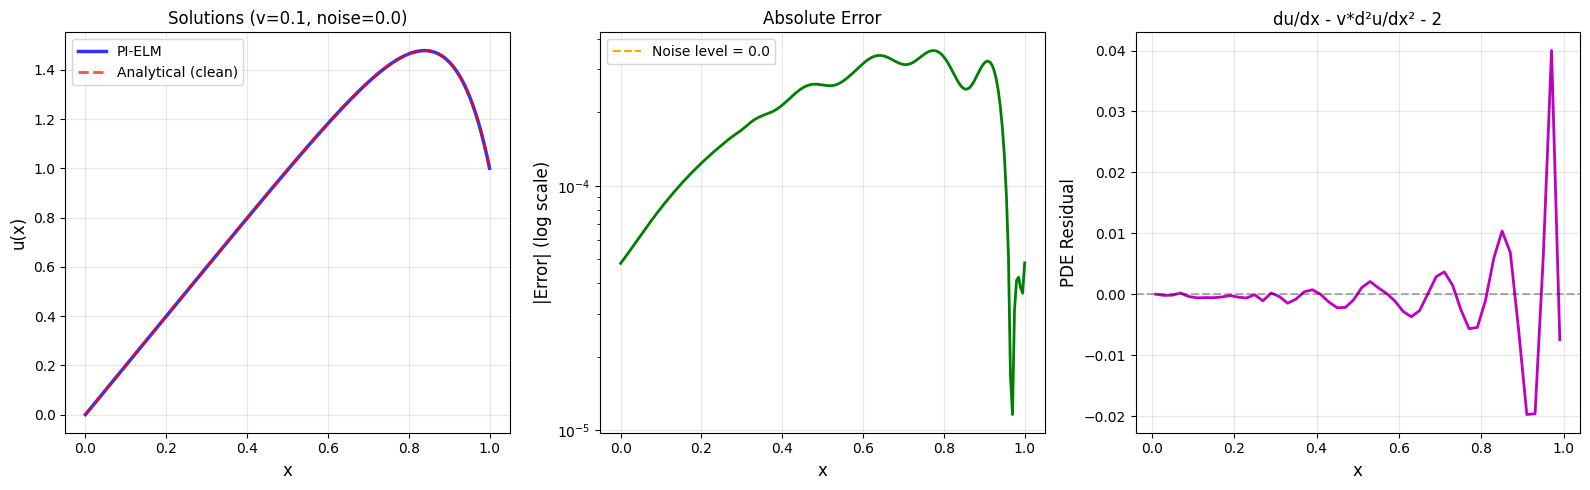


Performance Metrics:
Mean Absolute Error (MAE): 2.127515e-04
Root Mean Square Error (RMSE): 2.350516e-04
Max Absolute Error: 3.586095e-04

Boundary Check (Clean):
u(0) - Predicted: -0.000048, Expected: 0.0, Error: 4.817782e-05
u(1) - Predicted: 1.000048, Expected: 1.0, Error: 4.842570e-05



Testing with v = 0.1, Noise Level = 0.01
Training ... 
Number of collocation points: 1000
Noise level: 0.01 (SNR: ~100.0)
Original BCs: u(0)=0.0, u(1)=1.0
Noisy BCs: u(0)=-0.0109, u(1)=1.0100
Trial 1: Error=1.4140e-02, BC_Error=2.3158e-02, Cond=6.00e+19
Trial 2: Error=1.1466e-02, BC_Error=2.1839e-02, Cond=2.00e+20
Trial 3: Error=1.2971e-02, BC_Error=2.2489e-02, Cond=7.09e+19
Trial 10: Error=1.1636e-02, BC_Error=2.1968e-02, Cond=2.22e+19

Best solution selected with error: 2.1858e-01
Final condition number: 1.31e+20


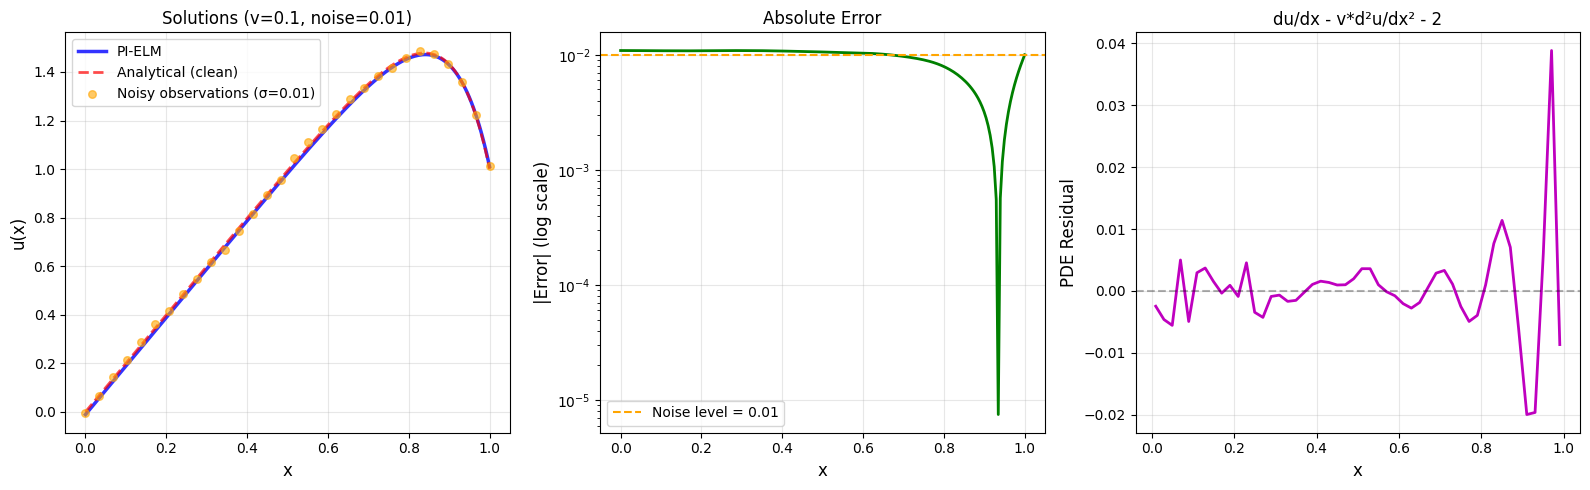


Performance Metrics:
Mean Absolute Error (MAE): 9.318988e-03
Root Mean Square Error (RMSE): 9.678013e-03
Max Absolute Error: 1.090350e-02

Boundary Check (Clean):
u(0) - Predicted: -0.010903, Expected: 0.0, Error: 1.090328e-02
u(1) - Predicted: 1.010021, Expected: 1.0, Error: 1.002067e-02



Testing with v = 0.1, Noise Level = 0.05
Training ... 
Number of collocation points: 1000
Noise level: 0.05 (SNR: ~20.0)
Original BCs: u(0)=0.0, u(1)=1.0
Noisy BCs: u(0)=-0.0543, u(1)=1.0499
Trial 1: Error=5.6550e-02, BC_Error=1.0908e-01, Cond=6.00e+19
Trial 2: Error=5.1715e-02, BC_Error=1.0654e-01, Cond=2.00e+20
Trial 3: Error=6.1181e-02, BC_Error=1.1070e-01, Cond=7.09e+19
Trial 10: Error=5.5802e-02, BC_Error=1.0872e-01, Cond=2.22e+19

Best solution selected with error: 1.0912e+00
Final condition number: 1.31e+20


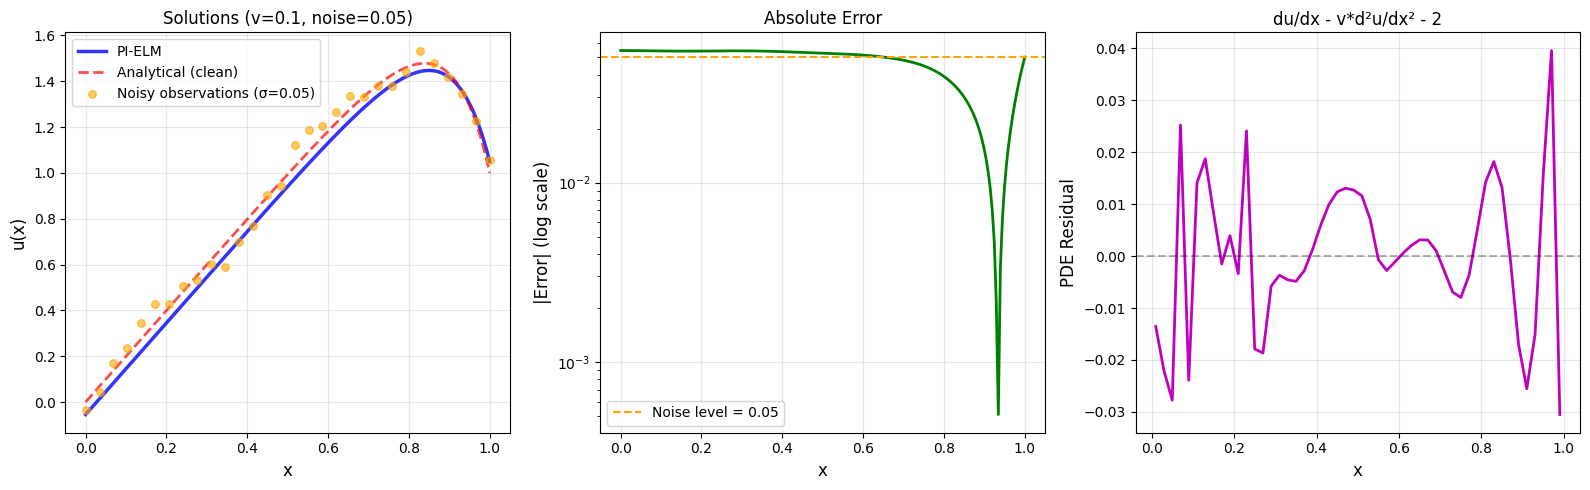


Performance Metrics:
Mean Absolute Error (MAE): 4.629014e-02
Root Mean Square Error (RMSE): 4.809713e-02
Max Absolute Error: 5.444500e-02

Boundary Check (Clean):
u(0) - Predicted: -0.054445, Expected: 0.0, Error: 5.444500e-02
u(1) - Predicted: 1.050032, Expected: 1.0, Error: 5.003177e-02



Testing with v = 0.1, Noise Level = 0.1
Training ... 
Number of collocation points: 1000
Noise level: 0.1 (SNR: ~10.0)
Original BCs: u(0)=0.0, u(1)=1.0
Noisy BCs: u(0)=-0.1086, u(1)=1.0997
Trial 1: Error=1.0541e-01, BC_Error=2.1451e-01, Cond=6.00e+19
Trial 2: Error=9.9908e-02, BC_Error=2.1141e-01, Cond=2.00e+20
Trial 3: Error=1.1612e-01, BC_Error=2.1842e-01, Cond=7.09e+19
Trial 10: Error=1.0807e-01, BC_Error=2.1575e-01, Cond=2.22e+19

Best solution selected with error: 2.1810e+00
Final condition number: 1.31e+20


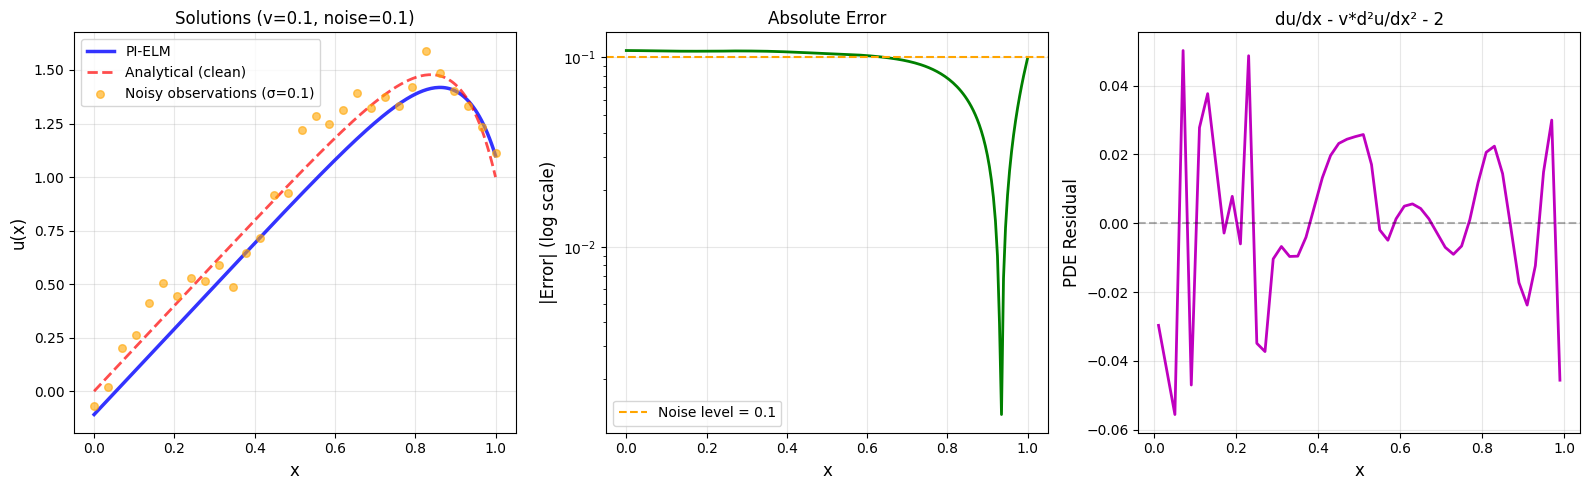


Performance Metrics:
Mean Absolute Error (MAE): 9.233265e-02
Root Mean Square Error (RMSE): 9.595515e-02
Max Absolute Error: 1.088315e-01

Boundary Check (Clean):
u(0) - Predicted: -0.108831, Expected: 0.0, Error: 1.088315e-01
u(1) - Predicted: 1.100005, Expected: 1.0, Error: 1.000047e-01




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class PIELM():
    def __init__(self, n_hidden=100, v=0.1):
        self.v = v
        self.n_hidden = n_hidden
        self.W = None
        self.b = None
        self.C = None
        self.pde_loss = None

    def _phi(self, Z):
        """Activation function"""
        return np.tanh(Z)

    def _phi_p(self, Z):
        """First derivative"""
        return 1 - np.tanh(Z)**2

    def _phi_pp(self, Z):
        """Second derivative"""
        return -2 * np.tanh(Z) * (1 - np.tanh(Z)**2)

    def _compute_Z(self, x):
        """Compute Z = W*x + b"""
        return self.W * x.reshape(1, -1) + self.b

    def _generate_collocation_points(self, Nc, x_min=0., x_max=1.):
        """Generate non-uniform collocation points clustered near boundary layer"""
        # Chebyshev-like clustering
        # x_uniform = np.linspace(x_min, x_max, Nc // 2)
        # theta = np.linspace(0, np.pi, Nc // 2 + 1)[:-1]
        # x_clustered = 0.75 + 0.25 * np.cos(theta)  # Cluster in [0.5, 1]

        # x_coll = np.unique(np.concatenate([x_uniform, x_clustered]))
        # x_coll = x_coll[(x_coll > x_min) & (x_coll < x_max)]
        x_coll = np.linspace(x_min, x_max, Nc)
        return x_coll

    def train(self, Nc=100, x_min=0., x_max=1., ul=0., ur=1., bc_weight=100.0, n_trials=5, noise_level=0.0):
        print("Training ... ")

        # Generate collocation points
        x_coll = self._generate_collocation_points(Nc, x_min, x_max)
        print(f"Number of collocation points: {len(x_coll)}")

        # Boundary points
        x_bc = np.array([x_min, x_max])
        u_bc = np.array([[ul], [ur]])

        # Add noise to boundary conditions if noise_level > 0
        if noise_level > 0:
            np.random.seed(123)  # For reproducibility of noise
            bc_noise = np.random.normal(0, noise_level, u_bc.shape)
            u_bc_noisy = u_bc + bc_noise
            print(f"Noise level: {noise_level} (SNR: ~{1/noise_level:.1f})")
            print(f"Original BCs: u(0)={ul}, u(1)={ur}")
            print(f"Noisy BCs: u(0)={u_bc_noisy[0,0]:.4f}, u(1)={u_bc_noisy[1,0]:.4f}")
        else:
            u_bc_noisy = u_bc
            print("Training with clean data (no noise)")

        best_error = np.inf
        best_C = None
        best_W = None
        best_b = None

        # Trials for best condition number
        for trial in range(n_trials):
            np.random.seed(42 + trial)

            # Mix of low and high frequency components
            W_low = np.random.randn(self.n_hidden // 2, 1) * 5.0
            W_high = np.random.randn(self.n_hidden // 2, 1) * 50.0
            self.W = np.vstack([W_low, W_high])
            self.b = np.random.randn(self.n_hidden, 1) * 5.0

            # Collocation points (enforce PDE)
            Z_coll = self._compute_Z(x_coll)
            phi_p_coll = self._phi_p(Z_coll)
            phi_pp_coll = self._phi_pp(Z_coll)

            H_op = (phi_p_coll * self.W).T - self.v * (phi_pp_coll * self.W**2).T

            # Boundary points
            Z_bc = self._compute_Z(x_bc)
            H_bc = self._phi(Z_bc).T

            # Weight boundary conditions more heavily
            H_bc_weighted = bc_weight * H_bc

            #  Right-hand side
            f_coll = 2 * np.ones((len(x_coll), 1))

            # Add noise to source term if noise_level > 0
            if noise_level > 0:
                f_noise = np.random.normal(0, noise_level, f_coll.shape)
                f_coll_noisy = f_coll + f_noise
            else:
                f_coll_noisy = f_coll

            u_bc_weighted = bc_weight * u_bc_noisy

            # Assemble system
            H_total = np.vstack([H_op, H_bc_weighted])
            b_total = np.vstack([f_coll_noisy, u_bc_weighted])

            # Solve for output weights
            HTH = H_total.T @ H_total
            HTb = H_total.T @ b_total

            # Adaptive regularization
            cond = np.linalg.cond(HTH)
            if cond > 1e12:
                lambda_reg = 1e-1
            elif cond > 1e8:
                lambda_reg = 1e-2
            else:
                lambda_reg = 1e-3

            # Increase regularization if noisy data
            if noise_level > 0:
                lambda_reg = max(lambda_reg, noise_level * 10)

            C_trial = np.linalg.solve(HTH + lambda_reg * np.eye(self.n_hidden), HTb)

            # Evaluate on clean validation points
            self.C = C_trial
            x_eval = np.linspace(x_min, x_max, 50)
            y_pred = self.predict(x_eval)
            y_exact = self.analytical_solution(x_eval)
            error = np.mean(np.abs(y_pred.flatten() - y_exact))

            # Check boundary conditions (against clean values)
            u0_pred = self.predict(np.array([x_min]))[0, 0]
            u1_pred = self.predict(np.array([x_max]))[0, 0]
            bc_error = abs(u0_pred - ul) + abs(u1_pred - ur)

            total_error = error + 10.0 * bc_error

            if total_error < best_error:
                best_error = total_error
                best_C = C_trial
                best_W = self.W.copy()
                best_b = self.b.copy()
                best_cond = cond

            if trial < 3 or trial == n_trials - 1:  # Print first 3 and last
                print(f"Trial {trial+1}: Error={error:.4e}, BC_Error={bc_error:.4e}, Cond={cond:.2e}")

        # Use best solution
        self.W = best_W
        self.b = best_b
        self.C = best_C

        print(f"\nBest solution selected with error: {best_error:.4e}")
        print(f"Final condition number: {best_cond:.2e}")

    def predict(self, x_test):
        """Predict u at test points"""
        Z_test = self._compute_Z(x_test)
        phi_test = self._phi(Z_test).T
        return phi_test @ self.C

    def analytical_solution(self, x):
        """
        Analytical solution for u_x - v*u_xx = 2
        """
        return (1 - np.exp(x/self.v)) / (np.exp(1/self.v) - 1) + 2*x

    def plot(self, x_test, noise_level=0.0, show_noisy_data=True):
        y_pred = self.predict(x_test)
        y_exact = self.analytical_solution(x_test)

        # Generate noisy observations for visualization
        if noise_level > 0 and show_noisy_data:
            np.random.seed(456)  # Different seed for test noise
            x_obs = np.linspace(0, 1, 30)  # Sparse observations
            y_obs_clean = self.analytical_solution(x_obs)
            noise = np.random.normal(0, noise_level, y_obs_clean.shape)
            y_obs_noisy = y_obs_clean + noise

        plt.figure(figsize=(16, 5))

        # Plot 1: Solutions
        plt.subplot(1, 3, 1)
        plt.plot(x_test, y_pred, 'b-', linewidth=2.5, label="PI-ELM", alpha=0.8)
        plt.plot(x_test, y_exact, 'r--', linewidth=2, label="Analytical (clean)", alpha=0.7)

        if noise_level > 0 and show_noisy_data:
            plt.scatter(x_obs, y_obs_noisy, c='orange', s=30, alpha=0.6, label=f"Noisy observations (σ={noise_level})", zorder=5)

        plt.xlabel('x', fontsize=12)
        plt.ylabel('u(x)', fontsize=12)
        plt.title(f'Solutions (v={self.v}, noise={noise_level})', fontsize=12)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)

        # Plot 2: Error
        plt.subplot(1, 3, 2)
        error = np.abs(y_pred.flatten() - y_exact)
        plt.semilogy(x_test, error, 'g-', linewidth=2)
        plt.axhline(y=noise_level, color='orange', linestyle='--',
                   label=f'Noise level = {noise_level}', linewidth=1.5)
        plt.xlabel('x', fontsize=12)
        plt.ylabel('|Error| (log scale)', fontsize=12)
        plt.title('Absolute Error', fontsize=12)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)

        # Plot 3: PDE Residual
        plt.subplot(1, 3, 3)
        x_check = np.linspace(0.01, 0.99, 50)
        residual = self.compute_residual(x_check)
        plt.plot(x_check, residual, 'm-', linewidth=2)
        plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        plt.xlabel('x', fontsize=12)
        plt.ylabel('PDE Residual', fontsize=12)
        plt.title('du/dx - v*d²u/dx² - 2', fontsize=12)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print metrics
        mae = np.mean(np.abs(y_pred.flatten() - y_exact))
        max_error = np.max(np.abs(y_pred.flatten() - y_exact))
        rmse = np.sqrt(np.mean((y_pred.flatten() - y_exact)**2))

        print(f"\nPerformance Metrics:")
        print(f"Mean Absolute Error (MAE): {mae:.6e}")
        print(f"Root Mean Square Error (RMSE): {rmse:.6e}")
        print(f"Max Absolute Error: {max_error:.6e}")

        # Check boundary conditions
        u0_pred = self.predict(np.array([0.0]))[0, 0]
        u1_pred = self.predict(np.array([1.0]))[0, 0]
        print(f"\nBoundary Check (Clean):")
        print(f"u(0) - Predicted: {u0_pred:.6f}, Expected: 0.0, Error: {abs(u0_pred):.6e}")
        print(f"u(1) - Predicted: {u1_pred:.6f}, Expected: 1.0, Error: {abs(u1_pred - 1.0):.6e}")

    def compute_residual(self, x):
        Z = self._compute_Z(x)
        phi = self._phi(Z)
        phi_p = self._phi_p(Z)
        phi_pp = self._phi_pp(Z)

        dudx = (phi_p * self.W).T @ self.C
        d2udx2 = (phi_pp * self.W**2).T @ self.C

        residual = dudx - 0.1 * d2udx2 - 2 # change self.v -> 0.1
        self.pde_loss = np.sum(residual.flatten())
        return residual.flatten()


# Test with different noise levels
if __name__ == "__main__":
    v = 0.1
    noise_levels = [0.0, 0.01, 0.05, 0.1]  # Different noise levels

    for noise in noise_levels:
        print(f"\n{'='*70}")
        print(f"Testing with v = {v}, Noise Level = {noise}")
        print(f"{'='*70}")

        model = PIELM(n_hidden=200, v=v)
        model.train(Nc=1000, x_min=0., x_max=1., ul=0., ur=1.,
                   bc_weight=100.0, n_trials=10, noise_level=noise)

        x_test = np.linspace(0, 1, 200)
        model.plot(x_test, noise_level=noise, show_noisy_data=True)

        print("\n" + "="*70 + "\n")

Case2: $$f(x) = 1 + 2\pi \cos(2\pi x) + 4v\pi^2 \sin(2\pi x)$$


Testing with v = 0.1, Noise Level = 0.0
Training ... 
Number of collocation points: 1000
Training with clean data (no noise)
Trial 1: Error=5.2745e-04, BC_Error=2.4881e-04, Cond=6.00e+19
Trial 2: Error=2.5671e-04, BC_Error=1.2174e-04, Cond=2.00e+20
Trial 3: Error=3.6084e-04, BC_Error=1.7002e-04, Cond=7.09e+19
Trial 10: Error=2.9044e-05, BC_Error=5.3534e-06, Cond=2.22e+19

Best solution selected with error: 1.6727e-05
Final condition number: 1.31e+20


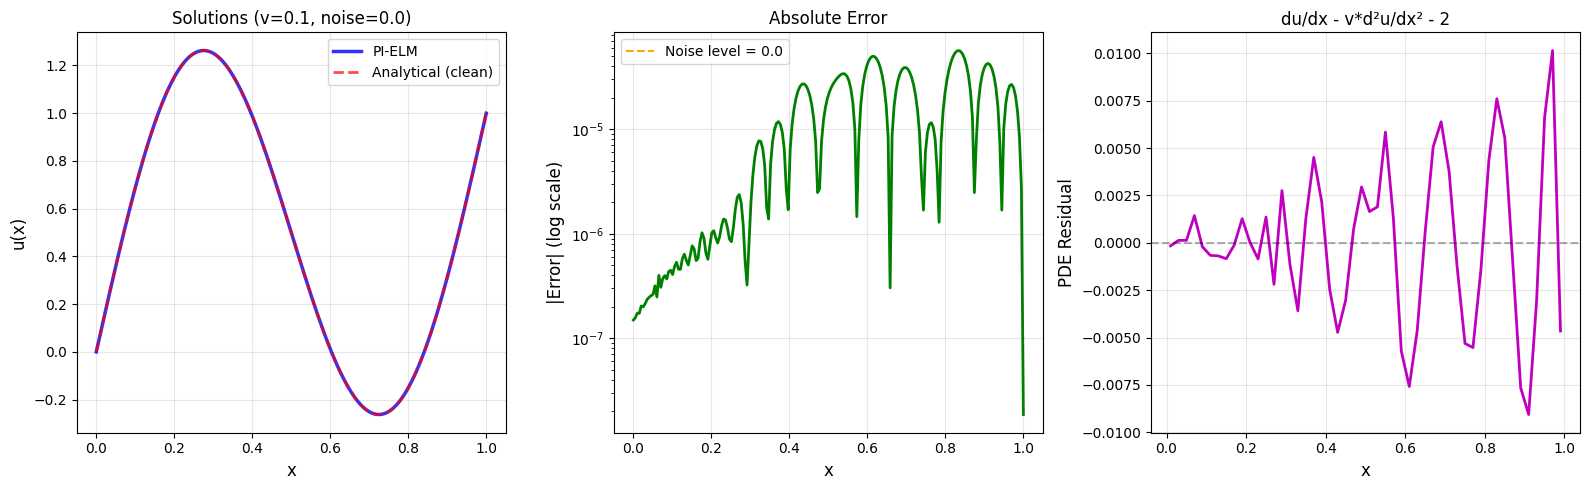


Performance Metrics:
Mean Absolute Error (MAE): 1.531200e-05
Root Mean Square Error (RMSE): 2.199996e-05
Max Absolute Error: 5.682213e-05

Boundary Check (Clean):
u(0) - Predicted: -0.000000, Expected: 0.0, Error: 1.490601e-07
u(1) - Predicted: 1.000000, Expected: 1.0, Error: 1.855239e-08



Testing with v = 0.1, Noise Level = 0.01
Training ... 
Number of collocation points: 1000
Noise level: 0.01 (SNR: ~100.0)
Original BCs: u(0)=0.0, u(1)=1.0
Noisy BCs: u(0)=-0.0109, u(1)=1.0100
Trial 1: Error=9.6697e-03, BC_Error=2.1034e-02, Cond=6.00e+19
Trial 2: Error=9.5600e-03, BC_Error=2.0931e-02, Cond=2.00e+20
Trial 3: Error=9.7702e-03, BC_Error=2.0964e-02, Cond=7.09e+19
Trial 10: Error=9.1917e-03, BC_Error=2.0799e-02, Cond=2.22e+19

Best solution selected with error: 2.1718e-01
Final condition number: 2.22e+19


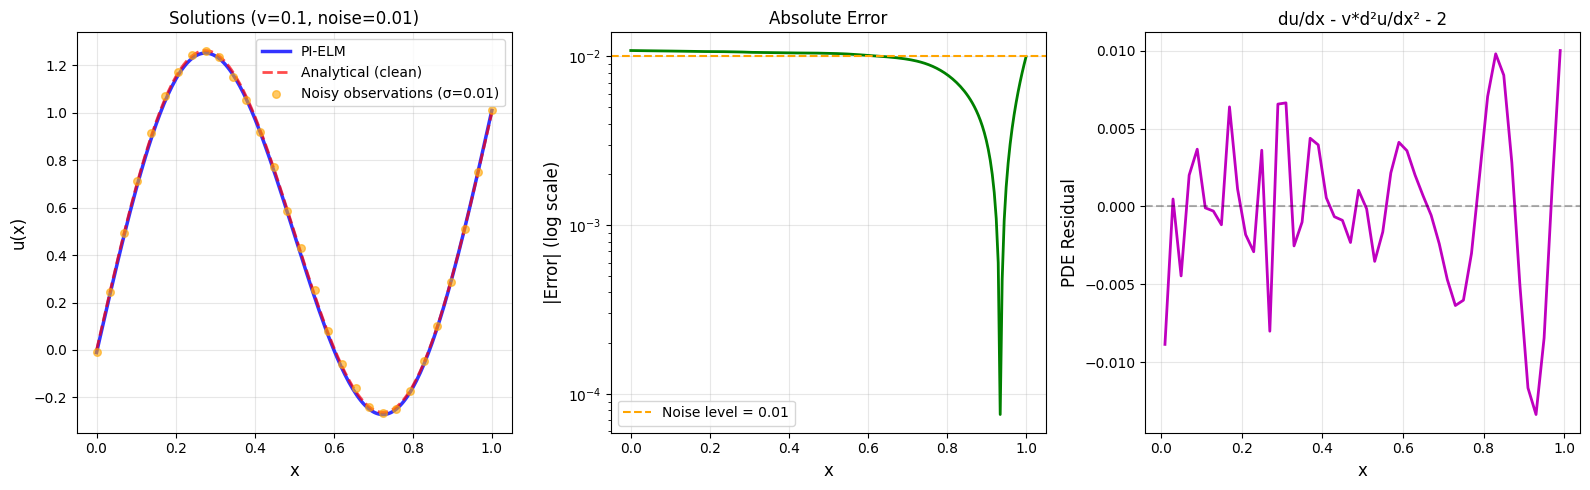


Performance Metrics:
Mean Absolute Error (MAE): 9.167729e-03
Root Mean Square Error (RMSE): 9.519920e-03
Max Absolute Error: 1.084090e-02

Boundary Check (Clean):
u(0) - Predicted: -0.010841, Expected: 0.0, Error: 1.084090e-02
u(1) - Predicted: 1.009958, Expected: 1.0, Error: 9.957893e-03



Testing with v = 0.1, Noise Level = 0.05
Training ... 
Number of collocation points: 1000
Noise level: 0.05 (SNR: ~20.0)
Original BCs: u(0)=0.0, u(1)=1.0
Noisy BCs: u(0)=-0.0543, u(1)=1.0499
Trial 1: Error=4.5756e-02, BC_Error=1.0390e-01, Cond=6.00e+19
Trial 2: Error=4.6719e-02, BC_Error=1.0413e-01, Cond=2.00e+20
Trial 3: Error=4.7689e-02, BC_Error=1.0423e-01, Cond=7.09e+19
Trial 10: Error=4.4877e-02, BC_Error=1.0345e-01, Cond=2.22e+19

Best solution selected with error: 1.0794e+00
Final condition number: 2.22e+19


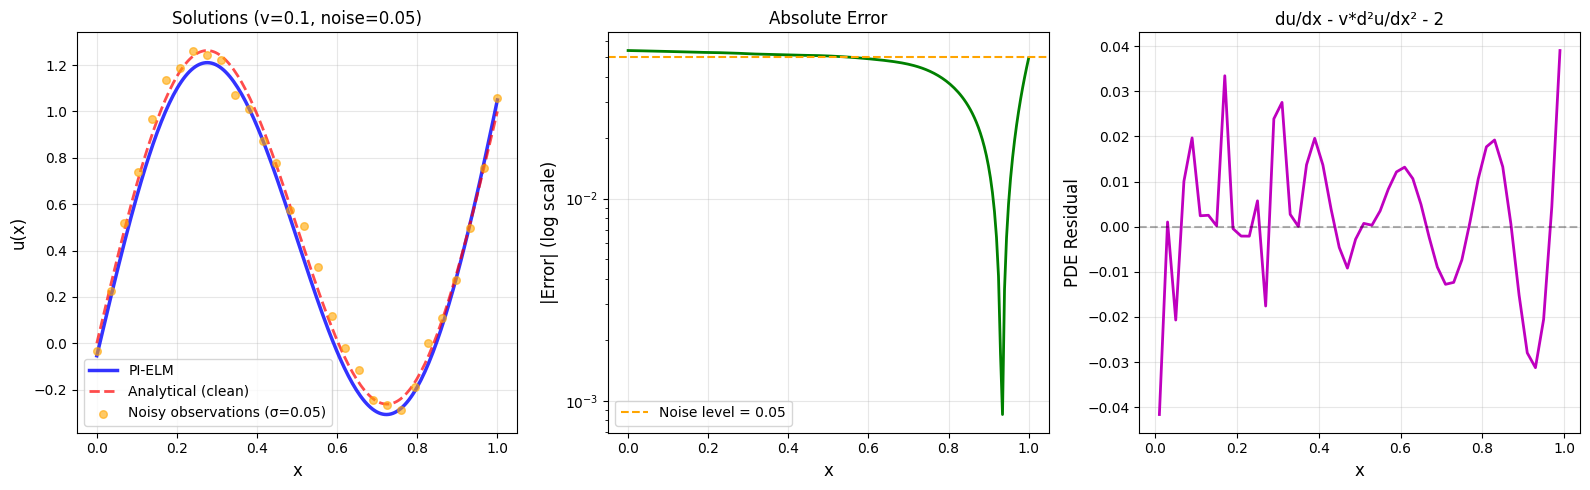


Performance Metrics:
Mean Absolute Error (MAE): 4.473345e-02
Root Mean Square Error (RMSE): 4.650586e-02
Max Absolute Error: 5.393360e-02

Boundary Check (Clean):
u(0) - Predicted: -0.053934, Expected: 0.0, Error: 5.393360e-02
u(1) - Predicted: 1.049518, Expected: 1.0, Error: 4.951788e-02



Testing with v = 0.1, Noise Level = 0.1
Training ... 
Number of collocation points: 1000
Noise level: 0.1 (SNR: ~10.0)
Original BCs: u(0)=0.0, u(1)=1.0
Noisy BCs: u(0)=-0.1086, u(1)=1.0997
Trial 1: Error=8.9649e-02, BC_Error=2.0690e-01, Cond=6.00e+19
Trial 2: Error=9.2492e-02, BC_Error=2.0780e-01, Cond=2.00e+20
Trial 3: Error=9.2676e-02, BC_Error=2.0712e-01, Cond=7.09e+19
Trial 10: Error=8.7626e-02, BC_Error=2.0584e-01, Cond=2.22e+19

Best solution selected with error: 2.1461e+00
Final condition number: 2.22e+19


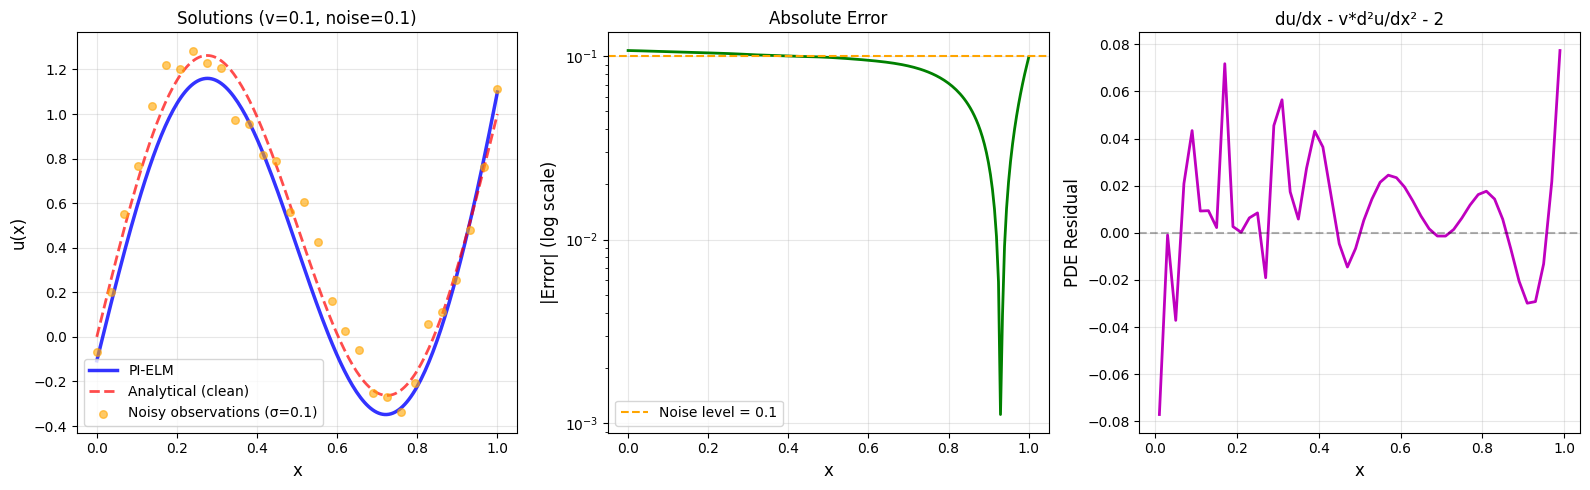


Performance Metrics:
Mean Absolute Error (MAE): 8.730020e-02
Root Mean Square Error (RMSE): 9.089007e-02
Max Absolute Error: 1.073377e-01

Boundary Check (Clean):
u(0) - Predicted: -0.107338, Expected: 0.0, Error: 1.073377e-01
u(1) - Predicted: 1.098505, Expected: 1.0, Error: 9.850488e-02




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class PIELM_oscillatory():
    def __init__(self, n_hidden=100, v=0.1):
        self.v = v
        self.n_hidden = n_hidden
        self.W = None
        self.b = None
        self.C = None
        self.pde_loss = None

    def _phi(self, Z):
        """Activation function"""
        return np.tanh(Z)

    def _phi_p(self, Z):
        """First derivative"""
        return 1 - np.tanh(Z)**2

    def _phi_pp(self, Z):
        """Second derivative"""
        return -2 * np.tanh(Z) * (1 - np.tanh(Z)**2)

    def _compute_Z(self, x):
        """Compute Z = W*x + b"""
        return self.W * x.reshape(1, -1) + self.b

    def _generate_collocation_points(self, Nc, x_min=0., x_max=1.):
        """Generate non-uniform collocation points clustered near boundary layer"""
        # For small v, boundary layer is near x=1 with thickness ~v
        # Chebyshev-like clustering
        # x_uniform = np.linspace(x_min, x_max, Nc // 2)
        # theta = np.linspace(0, np.pi, Nc // 2 + 1)[:-1]
        # x_clustered = 0.75 + 0.25 * np.cos(theta)  # Cluster in [0.5, 1]

        # x_coll = np.unique(np.concatenate([x_uniform, x_clustered]))
        # x_coll = x_coll[(x_coll > x_min) & (x_coll < x_max)]
        x_coll = np.linspace(x_min, x_max, Nc)
        return x_coll

    def train(self, Nc=100, x_min=0., x_max=1., ul=0., ur=1., bc_weight=100.0, n_trials=5, noise_level=0.0):
        print("Training ... ")

        # Generate collocation points
        x_coll = self._generate_collocation_points(Nc, x_min, x_max)
        print(f"Number of collocation points: {len(x_coll)}")

        # Boundary points
        x_bc = np.array([x_min, x_max])
        u_bc = np.array([[ul], [ur]])

        # Add noise to boundary conditions if noise_level > 0
        if noise_level > 0:
            np.random.seed(123)  # For reproducibility of noise
            bc_noise = np.random.normal(0, noise_level, u_bc.shape)
            u_bc_noisy = u_bc + bc_noise
            print(f"Noise level: {noise_level} (SNR: ~{1/noise_level:.1f})")
            print(f"Original BCs: u(0)={ul}, u(1)={ur}")
            print(f"Noisy BCs: u(0)={u_bc_noisy[0,0]:.4f}, u(1)={u_bc_noisy[1,0]:.4f}")
        else:
            u_bc_noisy = u_bc
            print("Training with clean data (no noise)")

        best_error = np.inf
        best_C = None
        best_W = None
        best_b = None

        # Trials for best condition number
        for trial in range(n_trials):
            np.random.seed(42 + trial)

            # Mix of low and high frequency components
            W_low = np.random.randn(self.n_hidden // 2, 1) * 5.0
            W_high = np.random.randn(self.n_hidden // 2, 1) * 50.0
            self.W = np.vstack([W_low, W_high])
            self.b = np.random.randn(self.n_hidden, 1) * 5.0

            # Collocation points (enforce PDE)
            Z_coll = self._compute_Z(x_coll)
            phi_p_coll = self._phi_p(Z_coll)
            phi_pp_coll = self._phi_pp(Z_coll)

            # Operator: L(phi_i) = phi'_i * W_i - v * phi''_i * W_i²
            H_op = (phi_p_coll * self.W).T - self.v * (phi_pp_coll * self.W**2).T

            # Boundary points
            Z_bc = self._compute_Z(x_bc)
            H_bc = self._phi(Z_bc).T

            # Weight boundary conditions more heavily
            H_bc_weighted = bc_weight * H_bc

            #  Right-hand side
            f_coll = 1 + 2*np.pi*np.cos(2*np.pi*x_coll) + 4*self.v*(np.pi**2)*np.sin(2*np.pi*x_coll)
            f_coll = f_coll.reshape(-1, 1)

            # Add noise to source term if noise_level > 0
            if noise_level > 0:
                f_noise = np.random.normal(0, noise_level, f_coll.shape)
                f_coll_noisy = f_coll + f_noise
            else:
                f_coll_noisy = f_coll

            u_bc_weighted = bc_weight * u_bc_noisy

            # Assemble system
            H_total = np.vstack([H_op, H_bc_weighted])
            b_total = np.vstack([f_coll_noisy, u_bc_weighted])

            # Solve for output weights
            HTH = H_total.T @ H_total
            HTb = H_total.T @ b_total

            # Adaptive regularization
            cond = np.linalg.cond(HTH)
            if cond > 1e12:
                lambda_reg = 1e-1
            elif cond > 1e8:
                lambda_reg = 1e-2
            else:
                lambda_reg = 1e-3

            # Increase regularization if noisy data
            if noise_level > 0:
                lambda_reg = max(lambda_reg, noise_level * 10)

            C_trial = np.linalg.solve(HTH + lambda_reg * np.eye(self.n_hidden), HTb)

            # Evaluate on clean validation points
            self.C = C_trial
            x_eval = np.linspace(x_min, x_max, 50)
            y_pred = self.predict(x_eval)
            y_exact = self.analytical_solution(x_eval)
            error = np.mean(np.abs(y_pred.flatten() - y_exact))

            # Check boundary conditions (against clean values)
            u0_pred = self.predict(np.array([x_min]))[0, 0]
            u1_pred = self.predict(np.array([x_max]))[0, 0]
            bc_error = abs(u0_pred - ul) + abs(u1_pred - ur)

            total_error = error + 10.0 * bc_error

            if total_error < best_error:
                best_error = total_error
                best_C = C_trial
                best_W = self.W.copy()
                best_b = self.b.copy()
                best_cond = cond

            if trial < 3 or trial == n_trials - 1:  # Print first 3 and last
                print(f"Trial {trial+1}: Error={error:.4e}, BC_Error={bc_error:.4e}, Cond={cond:.2e}")

        # Use best solution
        self.W = best_W
        self.b = best_b
        self.C = best_C

        print(f"\nBest solution selected with error: {best_error:.4e}")
        print(f"Final condition number: {best_cond:.2e}")

    def predict(self, x_test):
        """Predict u at test points"""
        Z_test = self._compute_Z(x_test)
        phi_test = self._phi(Z_test).T
        return phi_test @ self.C

    def analytical_solution(self, x):
        """MMS: Oscillatory solution"""
        return x + np.sin(2 * np.pi * x)

    def plot(self, x_test, noise_level=0.0, show_noisy_data=True):
        y_pred = self.predict(x_test)
        y_exact = self.analytical_solution(x_test)

        # Generate noisy observations for visualization
        if noise_level > 0 and show_noisy_data:
            np.random.seed(456)  # Different seed for test noise
            x_obs = np.linspace(0, 1, 30)  # Sparse observations
            y_obs_clean = self.analytical_solution(x_obs)
            noise = np.random.normal(0, noise_level, y_obs_clean.shape)
            y_obs_noisy = y_obs_clean + noise

        plt.figure(figsize=(16, 5))

        # Plot 1: Solutions
        plt.subplot(1, 3, 1)
        plt.plot(x_test, y_pred, 'b-', linewidth=2.5, label="PI-ELM", alpha=0.8)
        plt.plot(x_test, y_exact, 'r--', linewidth=2, label="Analytical (clean)", alpha=0.7)

        if noise_level > 0 and show_noisy_data:
            plt.scatter(x_obs, y_obs_noisy, c='orange', s=30, alpha=0.6, label=f"Noisy observations (σ={noise_level})", zorder=5)

        plt.xlabel('x', fontsize=12)
        plt.ylabel('u(x)', fontsize=12)
        plt.title(f'Solutions (v={self.v}, noise={noise_level})', fontsize=12)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)

        # Plot 2: Error
        plt.subplot(1, 3, 2)
        error = np.abs(y_pred.flatten() - y_exact)
        plt.semilogy(x_test, error, 'g-', linewidth=2)
        plt.axhline(y=noise_level, color='orange', linestyle='--', label=f'Noise level = {noise_level}', linewidth=1.5)
        plt.xlabel('x', fontsize=12)
        plt.ylabel('|Error| (log scale)', fontsize=12)
        plt.title('Absolute Error', fontsize=12)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)

        # Plot 3: PDE Residual
        plt.subplot(1, 3, 3)
        x_check = np.linspace(0.01, 0.99, 50)
        residual = self.compute_residual(x_check)
        plt.plot(x_check, residual, 'm-', linewidth=2)
        plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        plt.xlabel('x', fontsize=12)
        plt.ylabel('PDE Residual', fontsize=12)
        plt.title('du/dx - v*d²u/dx² - 2', fontsize=12)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print metrics
        mae = np.mean(np.abs(y_pred.flatten() - y_exact))
        max_error = np.max(np.abs(y_pred.flatten() - y_exact))
        rmse = np.sqrt(np.mean((y_pred.flatten() - y_exact)**2))

        print(f"\nPerformance Metrics:")
        print(f"Mean Absolute Error (MAE): {mae:.6e}")
        print(f"Root Mean Square Error (RMSE): {rmse:.6e}")
        print(f"Max Absolute Error: {max_error:.6e}")

        # Check boundary conditions
        u0_pred = self.predict(np.array([0.0]))[0, 0]
        u1_pred = self.predict(np.array([1.0]))[0, 0]
        print(f"\nBoundary Check (Clean):")
        print(f"u(0) - Predicted: {u0_pred:.6f}, Expected: 0.0, Error: {abs(u0_pred):.6e}")
        print(f"u(1) - Predicted: {u1_pred:.6f}, Expected: 1.0, Error: {abs(u1_pred - 1.0):.6e}")

    def compute_residual(self, x):
        Z = self._compute_Z(x)
        phi = self._phi(Z)
        phi_p = self._phi_p(Z)
        phi_pp = self._phi_pp(Z)

        dudx = (phi_p * self.W).T @ self.C
        d2udx2 = (phi_pp * self.W**2).T @ self.C

        f_x = (1 + 2*np.pi*np.cos(2*np.pi*x) + 4*self.v*(np.pi**2)*np.sin(2*np.pi*x)).reshape(-1, 1)
        residual = dudx - self.v * d2udx2 - f_x

        # residual = dudx - 0.1 * d2udx2 - 2 # change self.v -> 0.1
        self.pde_loss = np.sum(residual.flatten())
        return residual.flatten()


# Test with different noise levels
if __name__ == "__main__":
    v = 0.1
    noise_levels = [0.0, 0.01, 0.05, 0.1]  # Different noise levels

    for noise in noise_levels:
        print(f"\n{'='*70}")
        print(f"Testing with v = {v}, Noise Level = {noise}")
        print(f"{'='*70}")

        model = PIELM_oscillatory(n_hidden=200, v=v)
        model.train(Nc=1000, x_min=0., x_max=1., ul=0., ur=1.,
                   bc_weight=100.0, n_trials=10, noise_level=noise)

        x_test = np.linspace(0, 1, 200)
        model.plot(x_test, noise_level=noise, show_noisy_data=True)

        print("\n" + "="*70 + "\n")

**Inverse Modelling: Implement Diffusivity Coefficient Estimation**


Starting Inverse Problem (True v = 0.1)
Guess v: 1.000000 | Data Loss (MSE): 1.4395e-01
Guess v: 1.000000 | Data Loss (MSE): 1.4395e-01
Guess v: 0.937018 | Data Loss (MSE): 1.3976e-01
Guess v: 0.937018 | Data Loss (MSE): 1.3976e-01
Guess v: 0.866716 | Data Loss (MSE): 1.3448e-01
Guess v: 0.866716 | Data Loss (MSE): 1.3448e-01
Guess v: 0.585507 | Data Loss (MSE): 1.0407e-01
Guess v: 0.585507 | Data Loss (MSE): 1.0407e-01
Guess v: 0.001000 | Data Loss (MSE): 2.0225e-01
Guess v: 0.001000 | Data Loss (MSE): 2.0225e-01
Guess v: 0.424567 | Data Loss (MSE): 7.5616e-02
Guess v: 0.424567 | Data Loss (MSE): 7.5616e-02
Guess v: 0.353619 | Data Loss (MSE): 5.9203e-02
Guess v: 0.353619 | Data Loss (MSE): 5.9203e-02
Guess v: 0.309276 | Data Loss (MSE): 4.7659e-02
Guess v: 0.309276 | Data Loss (MSE): 4.7659e-02
Guess v: 0.155138 | Data Loss (MSE): 6.5288e-03
Guess v: 0.155138 | Data Loss (MSE): 6.5288e-03
Guess v: 0.070961 | Data Loss (MSE): 2.3726e-03
Guess v: 0.070961 | Data Loss (MSE): 2.3726e-03

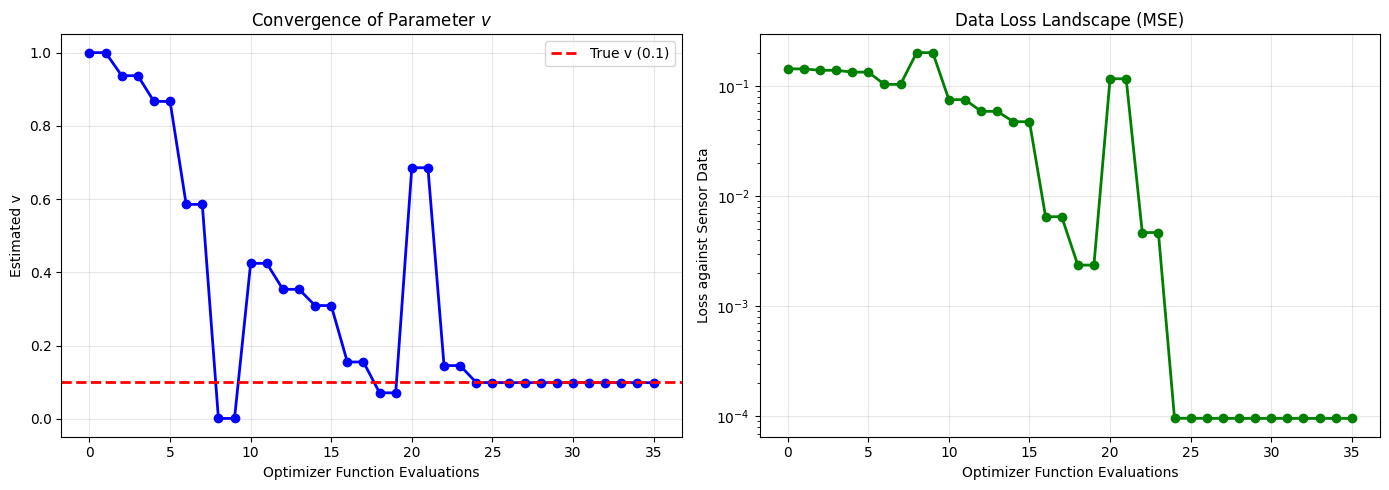

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

class PIELM_Inv():
    def __init__(self, n_hidden=100, v=0.1):
        self.v = v
        self.n_hidden = n_hidden
        self.W = None
        self.b = None
        self.C = None

    def _phi(self, Z):
        """Activation function"""
        return np.tanh(Z)

    def _phi_p(self, Z):
        """First derivative"""
        return 1 - np.tanh(Z)**2

    def _phi_pp(self, Z):
        """Second derivative"""
        return -2 * np.tanh(Z) * (1 - np.tanh(Z)**2)

    def _compute_Z(self, x):
        return self.W * x.reshape(1, -1) + self.b

    def _generate_collocation_points(self, Nc, x_min=0., x_max=1.):
        return np.linspace(x_min, x_max, Nc)

    def train(self, f_fixed, Nc=100, x_min=0., x_max=1., ul=0., ur=1., bc_weight=100.0, n_trials=1, noise_level=0.0):

        x_coll = self._generate_collocation_points(Nc, x_min, x_max)
        x_bc = np.array([x_min, x_max])
        u_bc = np.array([[ul], [ur]])

        best_error = np.inf
        best_C = None
        best_W = None
        best_b = None

        for trial in range(n_trials):
            np.random.seed(42 + trial)

            self.W = np.random.randn(self.n_hidden, 1) * 3.0
            self.b = np.random.randn(self.n_hidden, 1) * 3.0

            # Collocation points
            Z_coll = self._compute_Z(x_coll)
            phi_p_coll = self._phi_p(Z_coll)
            phi_pp_coll = self._phi_pp(Z_coll)

            H_op = (phi_p_coll * self.W).T - self.v * (phi_pp_coll * self.W**2).T

            # Boundary points
            Z_bc = self._compute_Z(x_bc)
            H_bc = self._phi(Z_bc).T
            H_bc_weighted = bc_weight * H_bc

            u_bc_weighted = bc_weight * u_bc

            # Assemble system
            H_total = np.vstack([H_op, H_bc_weighted])
            b_total = np.vstack([f_fixed, u_bc_weighted])

            # Solve
            HTH = H_total.T @ H_total
            HTb = H_total.T @ b_total

            lambda_reg = 1e-4
            if noise_level > 0:
                lambda_reg = max(lambda_reg, noise_level * 0.1)

            C_trial = np.linalg.solve(HTH + lambda_reg * np.eye(self.n_hidden), HTb)
            self.C = C_trial

            # Quick internal check
            y_pred_bc = self.predict(x_bc)
            bc_error = np.sum(np.abs(y_pred_bc - u_bc))

            if bc_error < best_error:
                best_error = bc_error
                best_C = C_trial
                best_W = self.W.copy()
                best_b = self.b.copy()

        self.W = best_W
        self.b = best_b
        self.C = best_C

    def predict(self, x_test):
        Z_test = self._compute_Z(x_test)
        phi_test = self._phi(Z_test).T
        return phi_test @ self.C


# INVERSE OPTIMIZATION LOOP
if __name__ == "__main__":
    v_true = 0.1
    noise_level = 0.01

    print(f"\n{'='*70}")
    print(f"Starting Inverse Problem (True v = {v_true})")
    print(f"{'='*70}")

    # TRUE physics forcing term (f_fixed)
    x_coll_train = np.linspace(0, 1, 1000)
    f_true = np.array([2.0]*len(x_coll_train))
    f_fixed_train = f_true.reshape(-1, 1)

    x_obs = np.linspace(0.05, 0.95, 20).reshape(-1, 1)
    u_true_obs = (1 - np.exp(x_obs/v_true)) / (np.exp(1/v_true) - 1) + 2*x_obs

    if noise_level > 0:
        np.random.seed(999) # Fixed seed so noise doesn't change during optimization
        u_true_obs += np.random.normal(0, noise_level, u_true_obs.shape)

    # Tracking arrays for plotting
    history_v = []
    history_loss = []

    # Objective Function
    def objective_function(v_guess):
        v_current = v_guess[0]
        model = PIELM_Inv(n_hidden=200, v=v_current)
        model.train(f_fixed=f_fixed_train, Nc=1000, n_trials=1, noise_level=noise_level)

        u_pred = model.predict(x_obs)
        data_loss = np.mean(np.square(u_pred - u_true_obs))

        history_v.append(v_current)
        history_loss.append(data_loss)

        print(f"Guess v: {v_current:.6f} | Data Loss (MSE): {data_loss:.4e}")
        return data_loss


    initial_guess = [2.0]

    # L-BFGS-B
    result = opt.minimize(
        objective_function,
        initial_guess,
        method='L-BFGS-B',
        bounds=[(0.001, 1.0)],
        options={'ftol': 1e-9, 'gtol': 1e-7} # Force it to be precise
    )

    print("\n" + "="*70)
    print(f"Optimization Finished!")
    print(f"True v: {v_true}")
    print(f"Estimated v: {result.x[0]:.6f}")
    print("="*70 + "\n")

    # 6. Plot the results
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history_v, 'bo-', linewidth=2)
    plt.axhline(y=v_true, color='r', linestyle='--', label='True v (0.1)', linewidth=2)
    plt.title('Convergence of Parameter $v$')
    plt.xlabel('Optimizer Function Evaluations')
    plt.ylabel('Estimated v')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.semilogy(history_loss, 'go-', linewidth=2)
    plt.title('Data Loss Landscape (MSE)')
    plt.xlabel('Optimizer Function Evaluations')
    plt.ylabel('Loss against Sensor Data')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

case2: $ u(x) = x + sin(2*π*x) $


Starting Inverse Problem (True v = 0.1)
Guess v: 1.000000 | Data Loss (MSE): 4.3694e-01
Guess v: 1.000000 | Data Loss (MSE): 4.3694e-01
Guess v: 0.921506 | Data Loss (MSE): 4.3030e-01
Guess v: 0.921506 | Data Loss (MSE): 4.3030e-01
Guess v: 0.830508 | Data Loss (MSE): 4.2120e-01
Guess v: 0.830508 | Data Loss (MSE): 4.2120e-01
Guess v: 0.466517 | Data Loss (MSE): 3.5224e-01
Guess v: 0.466517 | Data Loss (MSE): 3.5224e-01
Guess v: 0.001000 | Data Loss (MSE): 6.1249e-01
Guess v: 0.001000 | Data Loss (MSE): 6.1249e-01
Guess v: 0.276534 | Data Loss (MSE): 2.4177e-01
Guess v: 0.276534 | Data Loss (MSE): 2.4177e-01
Guess v: 0.123113 | Data Loss (MSE): 1.5754e-02
Guess v: 0.123113 | Data Loss (MSE): 1.5754e-02
Guess v: 0.108046 | Data Loss (MSE): 2.2814e-03
Guess v: 0.108046 | Data Loss (MSE): 2.2814e-03
Guess v: 0.099817 | Data Loss (MSE): 1.0103e-04
Guess v: 0.099817 | Data Loss (MSE): 1.0103e-04
Guess v: 0.208590 | Data Loss (MSE): 1.5686e-01
Guess v: 0.208590 | Data Loss (MSE): 1.5686e-01

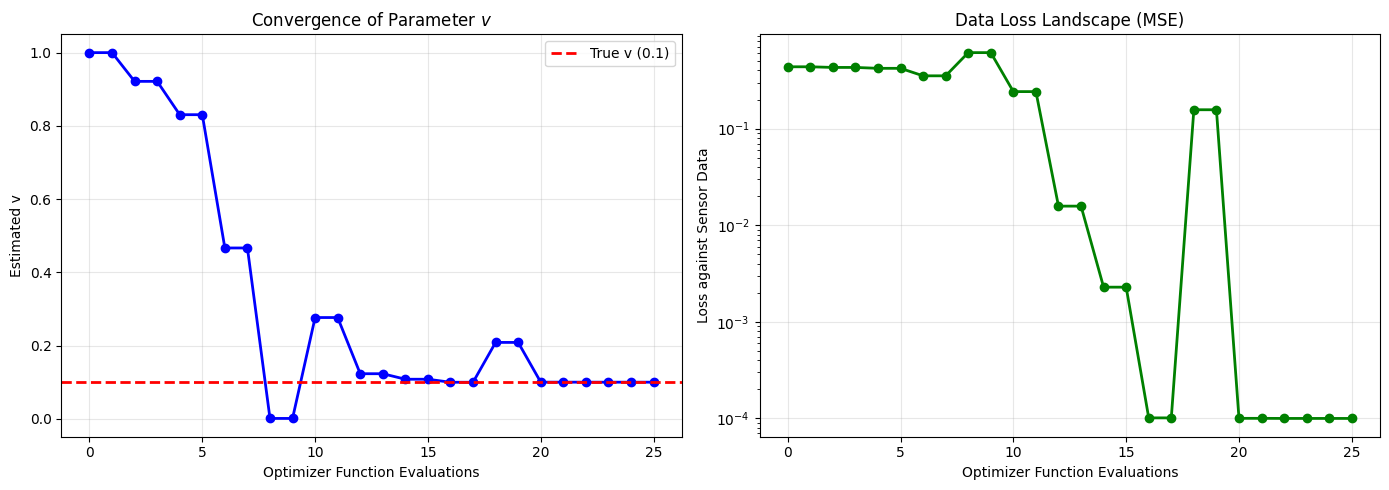

In [ ]:
v_true = 0.1
noise_level = 0.01

print(f"\n{'='*70}")
print(f"Starting Inverse Problem (True v = {v_true})")
print(f"{'='*70}")

x_coll_train = np.linspace(0, 1, 1000)
f_true = 1 + 2*np.pi*np.cos(2*np.pi*x_coll_train) + 4*v_true*(np.pi**2)*np.sin(2*np.pi*x_coll_train)
f_fixed_train = f_true.reshape(-1, 1)

x_obs = np.linspace(0.05, 0.95, 20).reshape(-1, 1)
u_true_obs = x_obs + np.sin(2 * np.pi * x_obs)

if noise_level > 0:
    np.random.seed(999)
    u_true_obs += np.random.normal(0, noise_level, u_true_obs.shape)

history_v = []
history_loss = []

def objective_function(v_guess):
    v_current = v_guess[0]
    model = PIELM_Inv(n_hidden=200, v=v_current)
    model.train(f_fixed=f_fixed_train, Nc=1000, n_trials=1, noise_level=noise_level)

    u_pred = model.predict(x_obs)
    data_loss = np.mean(np.square(u_pred - u_true_obs))

    history_v.append(v_current)
    history_loss.append(data_loss)

    print(f"Guess v: {v_current:.6f} | Data Loss (MSE): {data_loss:.4e}")
    return data_loss

initial_guess = [3.0]

result = opt.minimize(
    objective_function,
    initial_guess,
    method='L-BFGS-B',
    bounds=[(0.001, 1.0)],
    options={'ftol': 1e-9, 'gtol': 1e-7} # Force it to be precise
)

print("\n" + "="*70)
print(f"Optimization Finished!")
print(f"True v: {v_true}")
print(f"Estimated v: {result.x[0]:.6f}")
print("="*70 + "\n")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v, 'bo-', linewidth=2)
plt.axhline(y=v_true, color='r', linestyle='--', label='True v (0.1)', linewidth=2)
plt.title('Convergence of Parameter $v$')
plt.xlabel('Optimizer Function Evaluations')
plt.ylabel('Estimated v')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.semilogy(history_loss, 'go-', linewidth=2)
plt.title('Data Loss Landscape (MSE)')
plt.xlabel('Optimizer Function Evaluations')
plt.ylabel('Loss against Sensor Data')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

case3: $ u(x) = 1 + 0.4*\pi*cos(0.4*\pi*x) + 0.5*\pi*cos(10*\pi*x) $


Starting Inverse Problem (True v = 0.1)
Guess v: 1.000000 | Data Loss (MSE): 5.3123e-03
Guess v: 1.000000 | Data Loss (MSE): 5.3123e-03
Guess v: 0.998944 | Data Loss (MSE): 5.3112e-03
Guess v: 0.998944 | Data Loss (MSE): 5.3112e-03
Guess v: 0.997886 | Data Loss (MSE): 5.3101e-03
Guess v: 0.997886 | Data Loss (MSE): 5.3101e-03
Guess v: 0.993652 | Data Loss (MSE): 5.3055e-03
Guess v: 0.993652 | Data Loss (MSE): 5.3055e-03
Guess v: 0.976717 | Data Loss (MSE): 5.2872e-03
Guess v: 0.976717 | Data Loss (MSE): 5.2872e-03
Guess v: 0.908977 | Data Loss (MSE): 5.2074e-03
Guess v: 0.908977 | Data Loss (MSE): 5.2074e-03
Guess v: 0.638019 | Data Loss (MSE): 4.7403e-03
Guess v: 0.638019 | Data Loss (MSE): 4.7403e-03
Guess v: 0.001000 | Data Loss (MSE): 9.9843e-02
Guess v: 0.001000 | Data Loss (MSE): 9.9843e-02
Guess v: 0.433347 | Data Loss (MSE): 4.0628e-03
Guess v: 0.433347 | Data Loss (MSE): 4.0628e-03
Guess v: 0.166577 | Data Loss (MSE): 1.3851e-03
Guess v: 0.166577 | Data Loss (MSE): 1.3851e-03

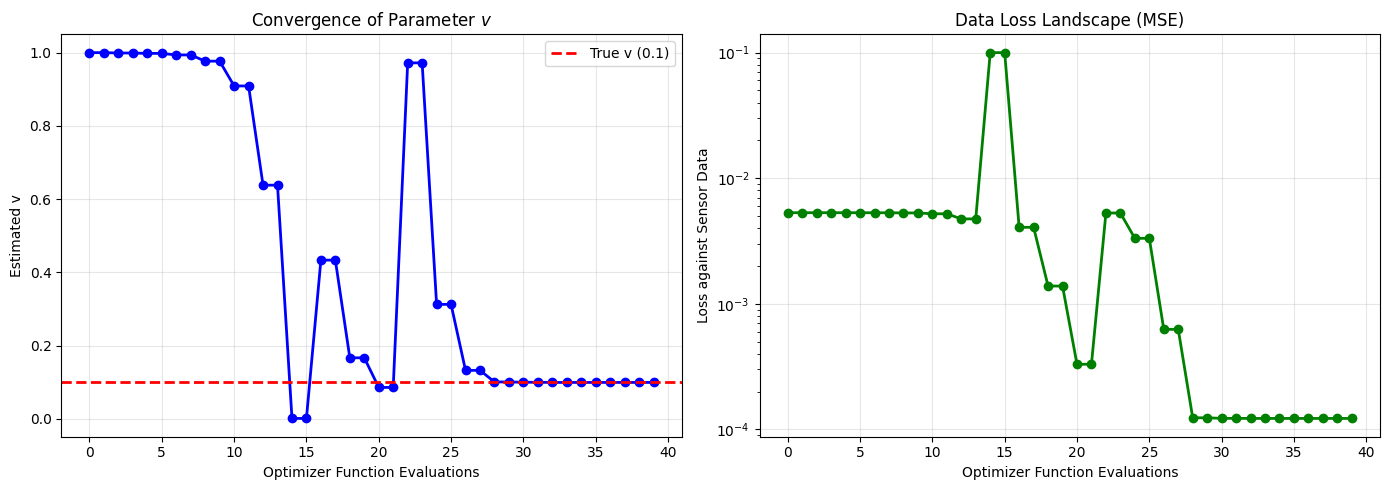

In [ ]:
v_true = 0.1
noise_level = 0.01

print(f"\n{'='*70}")
print(f"Starting Inverse Problem (True v = {v_true})")
print(f"{'='*70}")

x_coll_train = np.linspace(0, 1, 1000)
u_x = 1.0 + 0.4*np.pi*np.cos(4*np.pi*x_coll_train) + 0.5*np.pi*np.cos(10*np.pi*x_coll_train)
u_xx = -1.6*(np.pi**2)*np.sin(4*np.pi*x_coll_train) - 5.0*(np.pi**2)*np.sin(10*np.pi*x_coll_train)

f_true = u_x - v_true * u_xx
f_fixed_train = f_true.reshape(-1, 1)

u_true_obs = x_obs + 0.1*np.sin(4*np.pi*x_obs) + 0.05*np.sin(10*np.pi*x_obs)

if noise_level > 0:
    np.random.seed(999)
    u_true_obs += np.random.normal(0, noise_level, u_true_obs.shape)

history_v = []
history_loss = []

def objective_function(v_guess):
    v_current = v_guess[0]
    model = PIELM_Inv(n_hidden=200, v=v_current)
    model.train(f_fixed=f_fixed_train, Nc=1000, n_trials=1, noise_level=noise_level)

    u_pred = model.predict(x_obs)
    data_loss = np.mean(np.square(u_pred - u_true_obs))

    history_v.append(v_current)
    history_loss.append(data_loss)

    print(f"Guess v: {v_current:.6f} | Data Loss (MSE): {data_loss:.4e}")
    return data_loss

initial_guess = [3.0]

result = opt.minimize(
    objective_function,
    initial_guess,
    method='L-BFGS-B',
    bounds=[(0.001, 1.0)],
    options={'ftol': 1e-9, 'gtol': 1e-7} # Force it to be precise
)

print("\n" + "="*70)
print(f"Optimization Finished!")
print(f"True v: {v_true}")
print(f"Estimated v: {result.x[0]:.6f}")
print("="*70 + "\n")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v, 'bo-', linewidth=2)
plt.axhline(y=v_true, color='r', linestyle='--', label='True v (0.1)', linewidth=2)
plt.title('Convergence of Parameter $v$')
plt.xlabel('Optimizer Function Evaluations')
plt.ylabel('Estimated v')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.semilogy(history_loss, 'go-', linewidth=2)
plt.title('Data Loss Landscape (MSE)')
plt.xlabel('Optimizer Function Evaluations')
plt.ylabel('Loss against Sensor Data')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

case4: $u(x) = \frac{1}{2} \left[ 1 + \tanh\left(\frac{x - 0.5}{a}\right) \right]$ where $a=0.05$


Starting Inverse Problem (True v = 0.1)
Guess v: 1.000000 | Data Loss (MSE): 5.1642e-02
Guess v: 1.000000 | Data Loss (MSE): 5.1642e-02
Guess v: 0.988948 | Data Loss (MSE): 5.1519e-02
Guess v: 0.988948 | Data Loss (MSE): 5.1519e-02
Guess v: 0.977662 | Data Loss (MSE): 5.1390e-02
Guess v: 0.977662 | Data Loss (MSE): 5.1390e-02
Guess v: 0.932518 | Data Loss (MSE): 5.0846e-02
Guess v: 0.932518 | Data Loss (MSE): 5.0846e-02
Guess v: 0.751942 | Data Loss (MSE): 4.8055e-02
Guess v: 0.751942 | Data Loss (MSE): 4.8055e-02
Guess v: 0.029637 | Data Loss (MSE): 2.8475e-02
Guess v: 0.029637 | Data Loss (MSE): 2.8475e-02
Guess v: 0.736975 | Data Loss (MSE): 4.7766e-02
Guess v: 0.736975 | Data Loss (MSE): 4.7766e-02
Guess v: 0.383306 | Data Loss (MSE): 3.4866e-02
Guess v: 0.383306 | Data Loss (MSE): 3.4866e-02
Guess v: 0.147236 | Data Loss (MSE): 4.9246e-03
Guess v: 0.147236 | Data Loss (MSE): 4.9246e-03
Guess v: 0.103211 | Data Loss (MSE): 1.8208e-04
Guess v: 0.103211 | Data Loss (MSE): 1.8208e-04

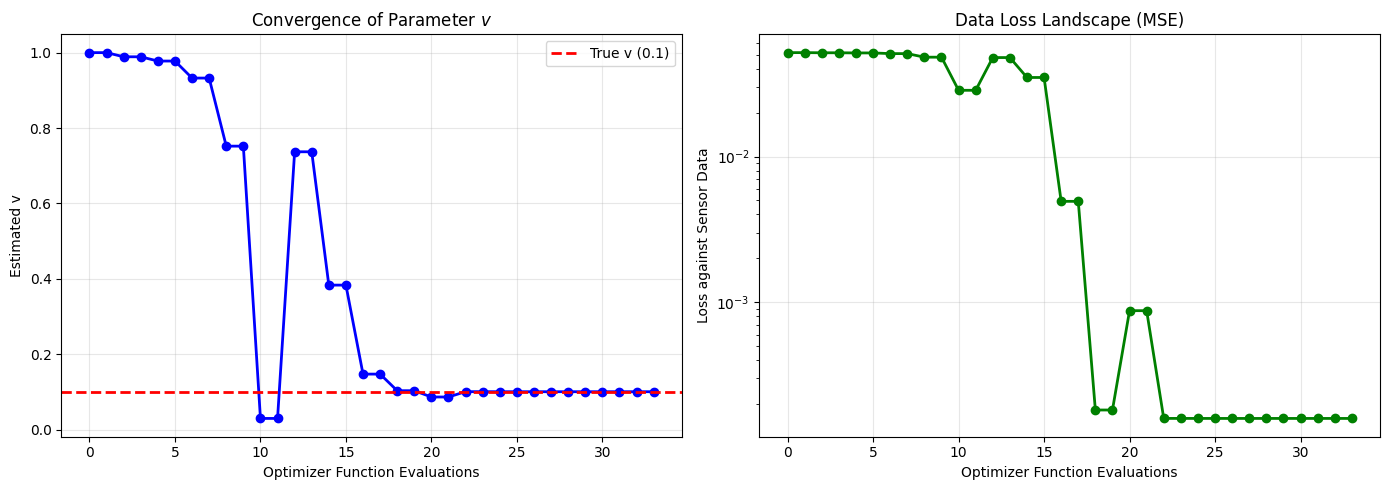

In [ ]:
v_true = 0.1
noise_level = 0.01

print(f"\n{'='*70}")
print(f"Starting Inverse Problem (True v = {v_true})")
print(f"{'='*70}")

x_coll_train = np.linspace(0, 1, 1000)

a = 0.05

z_coll = (x_coll_train - 0.5) / a
sech2_coll = 1.0 / np.cosh(z_coll)**2

u_x = (0.5 / a) * sech2_coll
u_xx = -(1.0 / a**2) * sech2_coll * np.tanh(z_coll)
f_true = u_x - v_true * u_xx
f_fixed_train = f_true.reshape(-1, 1)

z_obs = (x_obs - 0.5) / a
u_true_obs = 0.5 * (1.0 + np.tanh(z_obs))

if noise_level > 0:
    np.random.seed(999)
    u_true_obs += np.random.normal(0, noise_level, u_true_obs.shape)

history_v = []
history_loss = []

def objective_function(v_guess):
    v_current = v_guess[0]
    model = PIELM_Inv(n_hidden=200, v=v_current)
    model.train(f_fixed=f_fixed_train, Nc=1000, n_trials=1, noise_level=noise_level)

    u_pred = model.predict(x_obs)
    data_loss = np.mean(np.square(u_pred - u_true_obs))

    history_v.append(v_current)
    history_loss.append(data_loss)

    print(f"Guess v: {v_current:.6f} | Data Loss (MSE): {data_loss:.4e}")
    return data_loss

initial_guess = [3.0]

result = opt.minimize(
    objective_function,
    initial_guess,
    method='L-BFGS-B',
    bounds=[(0.001, 1.0)],
    options={'ftol': 1e-9, 'gtol': 1e-7} # Force it to be precise
)

print("\n" + "="*70)
print(f"Optimization Finished!")
print(f"True v: {v_true}")
print(f"Estimated v: {result.x[0]:.6f}")
print("="*70 + "\n")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_v, 'bo-', linewidth=2)
plt.axhline(y=v_true, color='r', linestyle='--', label='True v (0.1)', linewidth=2)
plt.title('Convergence of Parameter $v$')
plt.xlabel('Optimizer Function Evaluations')
plt.ylabel('Estimated v')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.semilogy(history_loss, 'go-', linewidth=2)
plt.title('Data Loss Landscape (MSE)')
plt.xlabel('Optimizer Function Evaluations')
plt.ylabel('Loss against Sensor Data')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()